In [162]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## Regression

In [163]:
df_reg = pd.read_csv("./data/bengaluru_house_prices.csv")

df_reg

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [164]:
print(df_reg.shape)

(13320, 9)


In [165]:
print(df_reg.info())


<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB
None


In [166]:
print(df_reg.describe())


               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [167]:
print(df_reg.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [168]:
#Drpping society column as it has more than 50% missing values
df_reg.drop('society', axis=1, inplace=True)
df_reg

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00


In [169]:
df_reg["size"] = df_reg["size"].str.extract("(\d+)").astype(float)
df_reg

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\TestUser123\AppData\Local\Temp\ipykernel_12944\3416448060.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_reg["size"] = df_reg["size"].str.extract("(\d+)").astype(float)


,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3.0,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2.0,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5.0,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4.0,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2.0,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4.0,4689,4.0,1.0,488.00


In [170]:
df_reg['size'] = df_reg['size'].fillna(df_reg['size'].mode()[0])
df_reg

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3.0,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2.0,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5.0,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4.0,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2.0,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4.0,4689,4.0,1.0,488.00


In [171]:
#drop the null ;ocation rpw& changing the data type of total_sqft column to float
df_reg.dropna(subset=['location'], inplace=True)

In [172]:
def convert_sqft(value):
    try:
        if isinstance(value, str) and "-" in value:
            low, high = value.split("-")
            return (float(low) + float(high)) / 2
        return float(value)
    except:
        return np.nan

In [173]:
df_reg["total_sqft"] = df_reg["total_sqft"].apply(convert_sqft)

In [174]:
df_reg

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3.0,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2.0,1200.0,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5.0,3453.0,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4.0,3600.0,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2.0,1141.0,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4.0,4689.0,4.0,1.0,488.00


In [175]:
# Null values in the 'total_sqft' column can be filled with the mean or median of the column. Here, we will fill them with the median value.
df_reg["total_sqft"]= df_reg["total_sqft"].fillna(df_reg["total_sqft"].median())

In [176]:
#Null values in bath and balcony columns will be filled with mode of the respective columns
df_reg['bath'] = df_reg['bath'].fillna(df_reg['bath'].mode()[0])
df_reg['balcony'] = df_reg['balcony'].fillna(df_reg['balcony'].mode()[0])

In [177]:
df_reg["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [178]:
location_counts = df_reg["location"].value_counts()

df_reg["location"] = df_reg["location"].where(
    df_reg["location"].map(location_counts) >= 10,
    "Other"
)

In [179]:
print("Number of unique locations:", df_reg["location"].nunique())

print(df_reg["location"].value_counts().tail())

Number of unique locations: 254
location
Kalkere                  10
1st Block Koramangala    10
Gunjur Palya             10
Dodsworth Layout         10
Nagadevanahalli          10
Name: count, dtype: int64


In [180]:
df_reg = pd.get_dummies(
    df_reg,
    columns=["area_type", "availability", "location"],
    drop_first=True
)

In [181]:
df_reg

,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_14-Nov,availability_15-Aug,...,location_Vijayanagar,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur
0,2.0,1056.0,2.0,1.0,39.07,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4.0,2600.0,5.0,3.0,120.00,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3.0,1440.0,2.0,3.0,62.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3.0,1521.0,3.0,1.0,95.00,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2.0,1200.0,2.0,1.0,51.00,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,5.0,3453.0,4.0,0.0,231.00,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
13316,4.0,3600.0,5.0,2.0,400.00,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
13317,2.0,1141.0,2.0,1.0,60.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13318,4.0,4689.0,4.0,1.0,488.00,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [182]:
X = df_reg.drop("price", axis=1)
y = df_reg["price"]

In [183]:
X.shape, y.shape

((13319, 340), (13319,))

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [185]:
# applying standard scaling to the features to normalize the data
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

In [186]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

In [187]:
model_reg = Sequential()

model_reg.add(
    Dense(
        20,
        input_shape=(X_train.shape[1],),
        activation="relu"
    )
)

model_reg.add(
    Dense(
        10,
        activation="relu"
    )
)

model_reg.add(
    Dense(
        10,
        activation="relu"
    )
)

model_reg.add(
    Dense(
        1,
        activation="linear"
    )
)

C:\Users\TestUser123\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [188]:
model_reg.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 20)             │         6,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,151 (27.93 KB)

 Trainable params: 7,151 (27.93 KB)

 Non-trainable params: 0 (0.00 B)

In [189]:
model_reg.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [190]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [191]:
history = model_reg.fit(
    X_train,
    y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9286 - mae: 0.4327 - val_loss: 0.4638 - val_mae: 0.3241
Epoch 2/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6601 - mae: 0.3271 - val_loss: 0.4382 - val_mae: 0.3093
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5381 - mae: 0.2921 - val_loss: 0.4602 - val_mae: 0.2820
Epoch 4/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4861 - mae: 0.2729 - val_loss: 0.4576 - val_mae: 0.2735
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4469 - mae: 0.2594 - val_loss: 0.4517 - val_mae: 0.2624
Epoch 6/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4227 - mae: 0.2519 - val_loss: 0.4378 - val_mae: 0.2550
Epoch 7/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4043 - mae: 0.2448 - val_loss: 0.4356 - val_mae: 0.2542
Epoch 8/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3848 - mae: 0.2430 - val_loss: 0.4499 - val_mae: 0.2526
Epoch 9/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

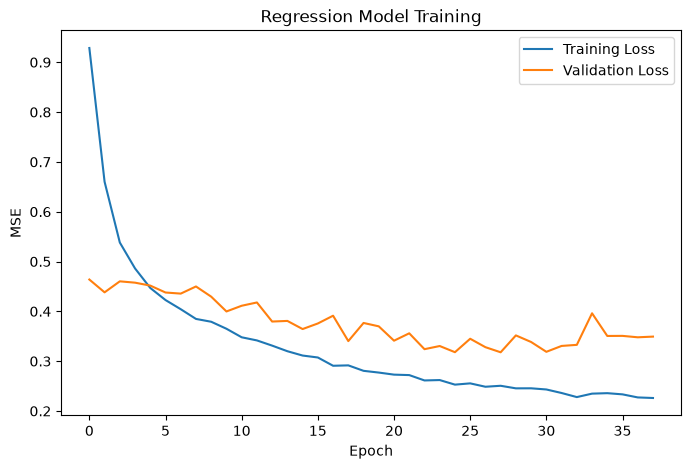

In [192]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Regression Model Training")

plt.legend()
plt.show()

In [193]:
y_pred_scaled = model_reg.predict(X_test)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [194]:
y_pred = scaler_y.inverse_transform(
    y_pred_scaled
).flatten()

In [195]:
y_test_original = y_test.values

In [196]:
mae = mean_absolute_error(
    y_test_original,
    y_pred
)

mse = mean_squared_error(
    y_test_original,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_original,
    y_pred
)

In [197]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 39.518696767675266
MSE : 9068.724368970354
RMSE: 95.22985019924349
R²  : 0.6111533297699521


In [198]:
results = pd.DataFrame({
    "Actual Price": y_test_original,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,29.5,146.944489
1,54.8,76.892471
2,53.0,53.525688
3,69.0,79.630852
4,56.0,62.041359
5,88.0,101.137093
6,75.0,116.291588
7,142.0,299.887512
8,160.0,118.632835
9,86.0,93.147049


## Classification

In [212]:
df_cls = pd.read_csv("./data/Churn_Modelling.csv")
df_cls

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [213]:
print(df_cls.shape)
print(df_cls.info())


(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None


In [214]:
print(df_cls.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [215]:
df_cls = df_cls.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

In [216]:
print(df_cls["Geography"].unique())
print(df_cls["Gender"].unique())

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [217]:
df_cls = pd.get_dummies(
    df_cls,
    columns=["Geography", "Gender"],
    drop_first=True
)

In [218]:
df_cls

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [219]:
X_cls = df_cls.drop("Exited", axis=1)
y_cls = df_cls["Exited"]

In [220]:
print(y_cls.value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [222]:
X_test_cls, X_train_cls, y_test_cls, y_train_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls

)

In [223]:
from sklearn.preprocessing import StandardScaler

scaler_cls = StandardScaler()

X_train_cls = scaler_cls.fit_transform(X_train_cls)

X_test_cls = scaler_cls.transform(X_test_cls)

In [224]:
print("X_train shape:", X_train_cls.shape)
print("X_test shape:", X_test_cls.shape)

X_train shape: (2000, 11)
X_test shape: (8000, 11)


In [225]:
input_dim_cls = X_train_cls.shape[1]

print("Input features:", input_dim_cls)

Input features: 11


In [226]:
model_cls = Sequential()

model_cls.add(
    Dense(
        20,
        input_shape=(input_dim_cls,),
        activation="relu"
    )
)

model_cls.add(
    Dense(
        10,
        activation="relu"
    )
)

model_cls.add(
    Dense(
        10,
        activation="relu"
    )
)

model_cls.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

C:\Users\TestUser123\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [227]:
model_cls.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

In [228]:
model_cls.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [229]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cls = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [230]:
history_cls = model_cls.fit(
    X_train_cls,
    y_train_cls,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_cls],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7981 - loss: 0.5308 - val_accuracy: 0.7800 - val_loss: 0.5290
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8006 - loss: 0.4780 - val_accuracy: 0.7800 - val_loss: 0.5122
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8006 - loss: 0.4583 - val_accuracy: 0.7800 - val_loss: 0.4987
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8006 - loss: 0.4425 - val_accuracy: 0.7800 - val_loss: 0.4901
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8006 - loss: 0.4297 - val_accuracy: 0.7800 - val_loss: 0.4848
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8006 - loss: 0.4199 - val_accuracy: 0.7825 - val_loss: 0.4797
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8031 - loss: 0.4109 - val_accuracy: 0.7850 - val_loss: 0.4774
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8119 - loss: 0.4034 - val_accuracy: 0.8075 - v

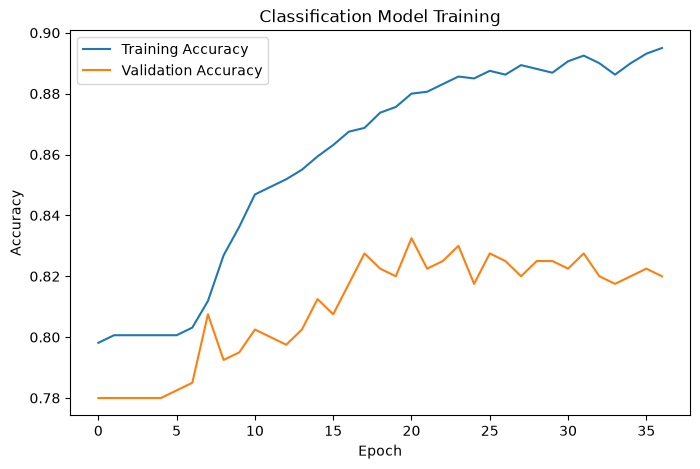

In [231]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cls.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cls.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classification Model Training")

plt.legend()
plt.show()

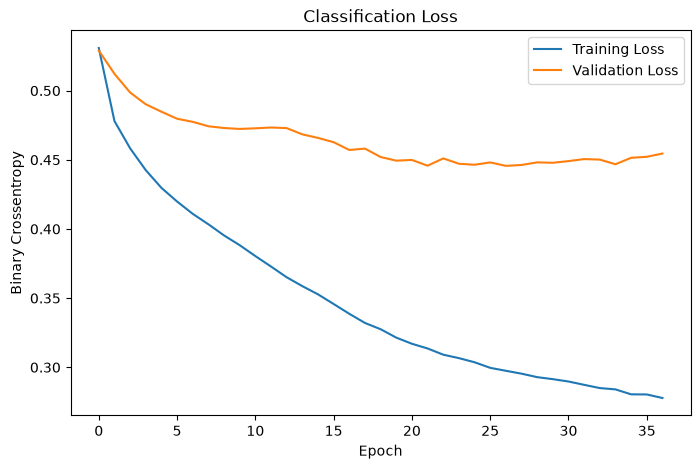

In [232]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cls.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cls.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.title("Classification Loss")

plt.legend()
plt.show()

In [233]:
y_prob = model_cls.predict(X_test_cls)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step


In [234]:
y_pred_cls = (y_prob >= 0.5).astype(int).flatten()

In [235]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_cls,
    y_pred_cls
)

print("Accuracy:", accuracy)

Accuracy: 0.842875


In [236]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_cls,
        y_pred_cls
    )
)

              precision    recall  f1-score   support

           0       0.87      0.94      0.91      6370
           1       0.66      0.46      0.55      1630

    accuracy                           0.84      8000
   macro avg       0.77      0.70      0.73      8000
weighted avg       0.83      0.84      0.83      8000



In [237]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

print(cm)

[[5989  381]
 [ 876  754]]


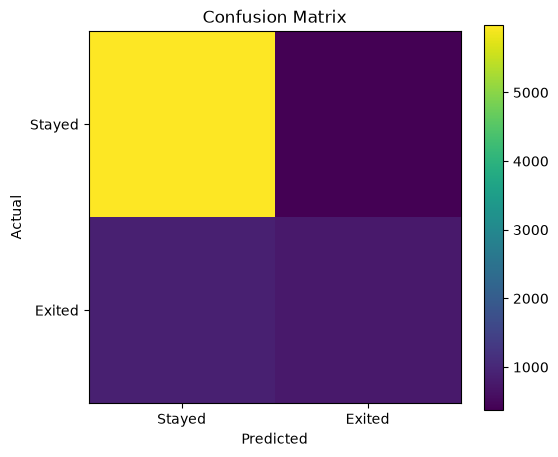

In [238]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Stayed", "Exited"])
plt.yticks([0, 1], ["Stayed", "Exited"])

plt.colorbar()
plt.show()